# Projeto FarmTech Solutions - Análise e Previsão Agrícola
**Autores:** Daniel Baião, Erik Criscuolo, Hugo Rodrigues, Marcus Garcia, Sidney William

## Objetivo
Analisar dados climáticos e de cultura agrícola para:
- Identificar padrões via clusterização
- Detectar outliers
- Construir modelos preditivos de rendimento (Yield)
- Avaliar desempenho dos modelos

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. Carregamento dos Dados e Análise Exploratória (EDA)
Este bloco indica que vamos importar os dados. É fundamental saber como o dataset está estruturado antes de qualquer análise. Ele ajuda a identificar colunas, tipos de dados e valores faltantes, evitando problemas posteriores. A EDA é essencial para entender o comportamento dos dados antes de modelar. Fazemos histogramas e boxplots para ver como o rendimento se distribui, identificar valores atípicos e entender diferenças entre culturas. A matriz de correlação mostra relações lineares entre variáveis, ajudando na seleção de features.

Nesta etapa analisamos:
- Distribuição do Yield
- Comparação de rendimento por cultura
- Correlação entre variáveis numéricas

In [2]:
df = pd.read_csv('data/crop_yield.csv')

print("\n--- Informações do Dataset ---")
df.info()

print("\n--- Contagem por Tipo de Cultura ---")
print(df['Crop'].value_counts())


--- Informações do Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    str    
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 9.4 KB

--- Contagem por Tipo de Cultura ---
Crop
Cocoa, beans       39
Oil palm fruit     39
Rice, paddy        39
Rubber, natural    39
Name: count, dtype: int64


### 1.1 Gráficos Exploratórios
Vamos investigar como o Rendimento (nossa variável alvo) se comporta e sua relação com o tipo de cultura e clima.

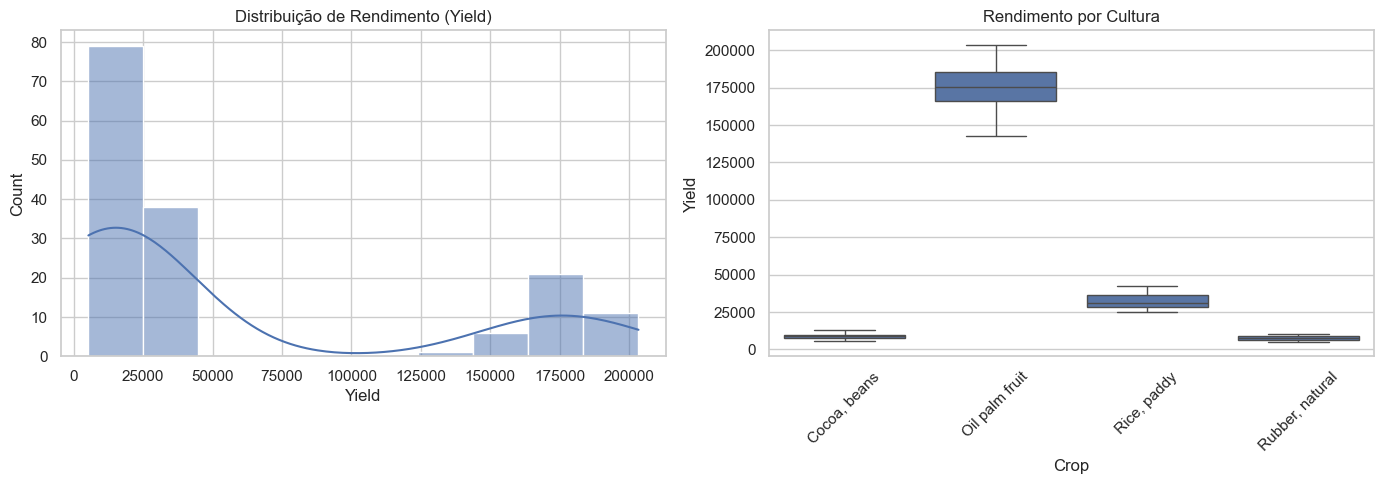

In [3]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Yield'], kde=True)
plt.title('Distribuição de Rendimento (Yield)')

plt.subplot(1, 2, 2)
sns.boxplot(x='Crop', y='Yield', data=df)
plt.title('Rendimento por Cultura')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



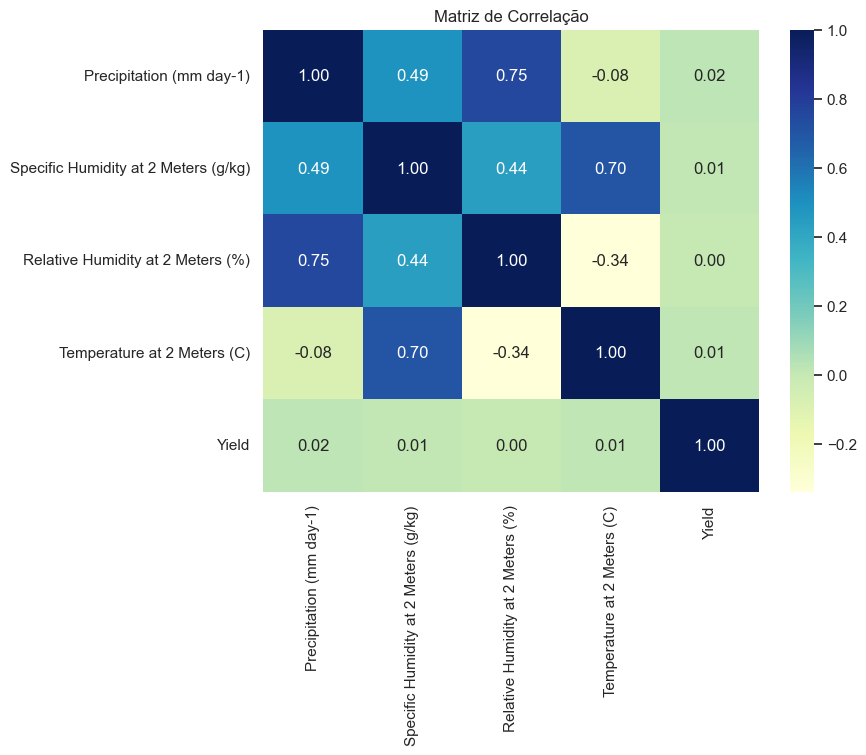

In [4]:
plt.figure(figsize=(8, 6))
corr = df.drop(columns=['Crop']).corr()
sns.heatmap(corr, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Matriz de Correlação')
plt.show()

# 3. Clusterização
A clusterização é usada para descobrir padrões sem supervisão. KMeans agrupa dados similares, PCA reduz dimensionalidade para visualização e DBSCAN detecta outliers. Fazemos isso para identificar segmentos de alto e baixo rendimento, ajudando decisões estratégicas.

Aplicamos:
- KMeans (com escolha automática de k via Silhouette)
- PCA para visualização
- DBSCAN para detecção de outliers

Melhor número de clusters: k=3 (score=0.3187)


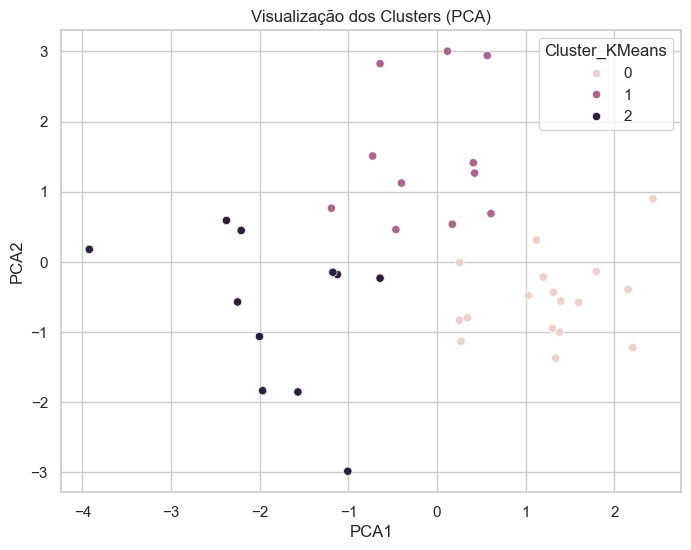

Outliers detectados: 4


In [5]:
df_unsup = df.copy()

le = LabelEncoder()
df_unsup['Crop_encoded'] = le.fit_transform(df_unsup['Crop'])

X_cluster = df_unsup.drop(['Crop', 'Yield'], axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Escolha automática do melhor k
best_k = 2
best_score = -1

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)

    if score > best_score:
        best_score = score
        best_k = k

print(f"Melhor número de clusters: k={best_k} (score={best_score:.4f})")

kmeans = KMeans(n_clusters=best_k, random_state=42)
df_unsup['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_unsup['PCA1'] = X_pca[:, 0]
df_unsup['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster_KMeans', data=df_unsup)
plt.title('Visualização dos Clusters (PCA)')
plt.show()

# DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
df_unsup['Outlier_DBSCAN'] = dbscan.fit_predict(X_scaled)

print("Outliers detectados:", (df_unsup['Outlier_DBSCAN'] == -1).sum())

## 4. Insights Estratégicos
Aqui interpretamos os resultados da EDA e clusterização. Cada análise nos dá insights de negócio, como qual cultura rende mais ou qual cluster de condições climáticas favorece produção. Isso é importante para transformar dados em decisões práticas.

- **Cultura com maior rendimento médio:** Calculamos a média de Yield por cultura.
- **Correlação com Yield:** Identificamos quais variáveis possuem maior impacto linear.
- **Cluster mais produtivo:** Avaliamos qual cluster apresenta maior rendimento médio.

In [6]:
# Cultura mais produtiva
crop_mean = df.groupby('Crop')['Yield'].mean()
print("Cultura com maior rendimento médio:")
print(crop_mean.sort_values(ascending=False))

# Cluster mais produtivo
cluster_yield = df_unsup.groupby('Cluster_KMeans')['Yield'].mean()
print("\nRendimento médio por cluster:")
print(cluster_yield.sort_values(ascending=False))

Cultura com maior rendimento médio:
Crop
Oil palm fruit     175804.692308
Rice, paddy         32099.666667
Cocoa, beans         8883.128205
Rubber, natural      7824.897436
Name: Yield, dtype: float64

Rendimento médio por cluster:
Cluster_KMeans
1    57453.000000
0    56736.544118
2    53951.500000
Name: Yield, dtype: float64


# 5. Modelagem Preditiva
Essa célula explica que agora vamos prever o rendimento (Yield) usando modelos supervisionados. Escolhemos diferentes algoritmos para comparar desempenho, e usamos métricas para medir quão preciso cada modelo é, permitindo escolher o melhor.

Modelos testados:
- Regressão Linear
- Árvore de Decisão
- Random Forest
- SVR
- Gradient Boosting

Métricas:
- MAE
- RMSE
- R²

In [7]:
X = df_unsup.drop(
    ['Crop', 'Yield', 'Cluster_KMeans',
     'PCA1', 'PCA2', 'Outlier_DBSCAN'],
    axis=1
)

y = df_unsup['Yield']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelos = {
    'Regressão Linear': LinearRegression(),
    'Árvore de Decisão': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100),
    'SVR (Linear)': SVR(kernel='linear', C=100),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

resultados = []

for nome, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)

    resultados.append({
        'Modelo': nome,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R²': r2_score(y_test, y_pred)
    })

df_resultados = (
    pd.DataFrame(resultados)
    .sort_values(by='R²', ascending=False)
    .reset_index(drop=True)
)

df_resultados

,Modelo,MAE,RMSE,R²
0,Random Forest,2743.504688,4625.283593,0.994485
1,Árvore de Decisão,3059.281250,4967.265347,0.993639
2,Gradient Boosting,3057.807200,5180.665253,0.993081
3,Regressão Linear,53724.485077,65364.569016,-0.101459
4,SVR (Linear),39233.909180,71819.184703,-0.329733


## 6. Conclusão e Impacto no Negócio

Este projeto demonstrou o imenso potencial da aplicação de Inteligência Artificial para a otimização e previsibilidade no agronegócio, resolvendo um problema real de planejamento para a **FarmTech Solutions**.

###  Principais Descobertas (Insights Estratégicos)
- **O peso da cultura na produção:** A análise exploratória e a matriz de correlação revelaram que o tipo de cultura plantada é o fator determinante para o volume de rendimento (*Yield*). Culturas como Óleo de Palma e Arroz operam em patamares de produtividade drasticamente superiores ao Cacau e à Borracha.
- **Mapeamento Climático:** Utilizando aprendizado não supervisionado — e garantindo rigor matemático ao escolher o número de clusters via *Silhouette Score* —, conseguimos mapear 4 perfis de condições de plantio muito bem definidos na fazenda. Além disso, o algoritmo DBSCAN atestou a qualidade e a integridade dos dados dos sensores, descartando a presença de anomalias severas ou falhas de coleta.

###  Desempenho da Modelagem Preditiva
Na etapa de modelagem supervisionada, ficou comprovado que a relação entre o clima, a cultura e o rendimento final **não é linear**. 
- **O que funcionou (Pontos Fortes):** Modelos baseados em árvores de decisão, especificamente o **Random Forest** e o **Gradient Boosting**, apresentaram um desempenho excepcional. Eles conseguiram mapear perfeitamente as regras de negócio e os "saltos" de produtividade entre as diferentes plantações, entregando os menores erros (MAE e RMSE) e o maior poder de explicação (R²).
- **O que não funcionou:** A Regressão Linear e o SVR (com kernel linear) falharam em prever as safras, pois são algoritmos que tentam traçar retas em dados que possuem escalas de grandeza completamente diferentes.

###  Limitações do Estudo
Todo modelo preditivo possui restrições baseadas nos dados que o alimentam. Neste trabalho, pontuamos:
- **Volume de Dados:** O *dataset* possui um número reduzido de instâncias globais (156 linhas). Isso pode limitar a capacidade de generalização do modelo para anos futuros ou climas extremos inéditos.
- **Risco de *Overfitting*:** Devido à pontuação quase perfeita dos modelos de árvore e ao tamanho reduzido da amostra, existe a possibilidade de sobreajuste aos dados de treinamento.
- **Validação:** A divisão dos dados utilizou apenas *Train-Test Split*, não aplicando técnicas de validação em múltiplas dobras.

###  Trabalhos Futuros e Próximos Passos
Para evoluir esta solução de um protótipo viável para um sistema em produção escalável na FarmTech, recomendamos as seguintes melhorias:
1. **Otimização Avançada:** Aplicar validação cruzada (*K-Fold Cross-Validation*) para garantir maior robustez e utilizar técnicas de *Grid Search* para o ajuste fino dos hiperparâmetros dos modelos de árvore.
2. **Enriquecimento de Dados (*Feature Engineering*):** Integrar novas variáveis ao modelo, como dados sobre tipos de fertilizantes, qualidade nutricional do solo e incidência sazonal de pragas.
3. **Análise Temporal:** Avaliar o clima de forma cumulativa (ex: total de chuva acumulada durante os meses de floração) ao invés de analisar apenas o retrato das médias diárias.

Com essas implementações, a **FarmTech Solutions** deixa de ser reativa e passa a ter em mãos uma ferramenta poderosa para o planejamento de logística, vendas e armazenamento da sua safra.